In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

ratings = pd.read_csv(
    "../data/ratings.csv",
    dtype={"userId": "int32", "movieId": "int32", "rating": "float32", "timestamp": "int64"}
)

movies = pd.read_csv(
    "../data/movies.csv",
    dtype={"movieId": "int32"}
)

print(ratings.shape, movies.shape)
ratings.head()

(32000204, 4) (87585, 3)


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [7]:
print(f"Number of users: {ratings['userId'].nunique():,}")
print(f"Number of movies: {ratings['movieId'].nunique():,}")
print(f"Number of ratings: {len(ratings):,}")

n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
sparsity = 1 - (len(ratings) / (n_users * n_movies))
print(f"Sparsity: {sparsity:.4f} ({sparsity*100:.2f}% of the user-movie matrix is empty)")

Number of users: 200,948
Number of movies: 84,432
Number of ratings: 32,000,204
Sparsity: 0.9981 (99.81% of the user-movie matrix is empty)


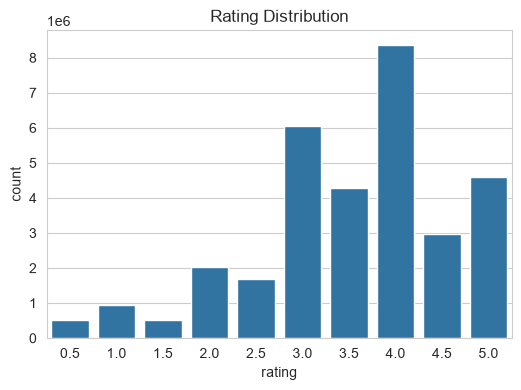

count    3.200020e+07
mean     3.540395e+00
std      1.058986e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=ratings)
plt.title("Rating Distribution")
plt.show()

print(ratings['rating'].describe())

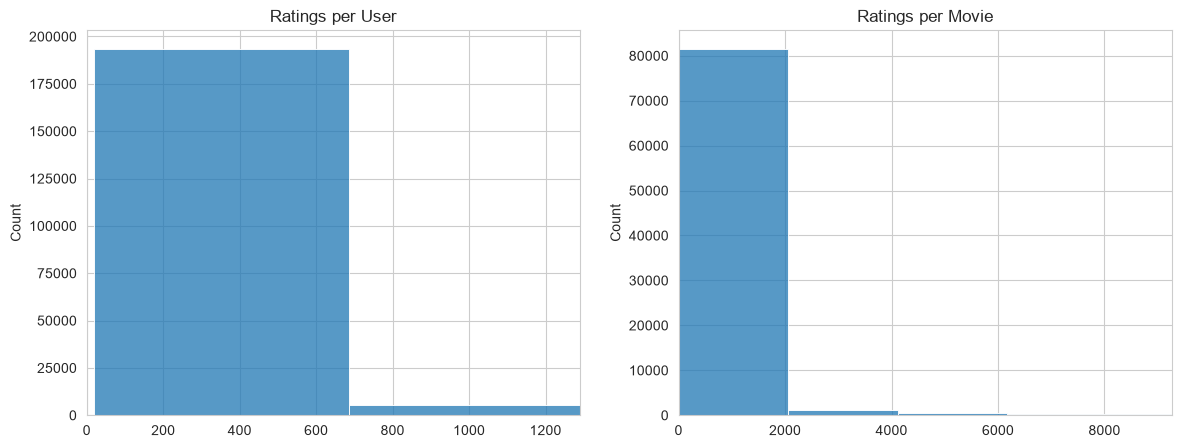

Median ratings per user: 73.0
Median ratings per movie: 5.0


In [9]:
ratings_per_user = ratings.groupby('userId').size()
ratings_per_movie = ratings.groupby('movieId').size()

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(ratings_per_user, bins=50, ax=axes[0])
axes[0].set_title("Ratings per User")
axes[0].set_xlim(0, ratings_per_user.quantile(0.99))  

sns.histplot(ratings_per_movie, bins=50, ax=axes[1])
axes[1].set_title("Ratings per Movie")
axes[1].set_xlim(0, ratings_per_movie.quantile(0.99))
plt.show()

print(f"Median ratings per user: {ratings_per_user.median()}")
print(f"Median ratings per movie: {ratings_per_movie.median()}")

In [10]:
movie_stats = ratings.groupby('movieId').agg(
    avg_rating=('rating', 'mean'),
    num_ratings=('rating', 'count')
).merge(movies, on='movieId')

print("Most rated movies:")
print(movie_stats.sort_values('num_ratings', ascending=False).head(10)[['title', 'num_ratings', 'avg_rating']])

print("\nHighest rated (min 1000 ratings):")
print(movie_stats[movie_stats['num_ratings'] >= 1000].sort_values('avg_rating', ascending=False).head(10)[['title', 'num_ratings', 'avg_rating']])

Most rated movies:
                                                  title  num_ratings  \
314                    Shawshank Redemption, The (1994)       102929   
351                                 Forrest Gump (1994)       100296   
292                                 Pulp Fiction (1994)        98409   
2480                                 Matrix, The (1999)        93808   
585                    Silence of the Lambs, The (1991)        90330   
257           Star Wars: Episode IV - A New Hope (1977)        85010   
2867                                  Fight Club (1999)        77332   
475                                Jurassic Park (1993)        75233   
522                             Schindler's List (1993)        73849   
4888  Lord of the Rings: The Fellowship of the Ring,...        73122   

      avg_rating  
314     4.404614  
351     4.052744  
292     4.196969  
2480    4.156436  
585     4.148367  
257     4.099823  
2867    4.228780  
475     3.698623  
522     4.236990 